In [37]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

In [38]:
import subprocess
from pathlib import Path

N = 100
EXE_PATH = "./tools/target/release/vis.exe"
for i in range(N):
    input_txt_path = f"./in/{str(i).zfill(4)}.txt"
    output_txt_path = f"./out/{str(i).zfill(4)}.txt"
    result_txt_path = f"./result/{str(i).zfill(4)}.txt"
    ret = subprocess.run([EXE_PATH, input_txt_path, output_txt_path, result_txt_path])

In [39]:
class Env:

    def __init__(self, input_txt_path: Path, output_txt_path, result_txt_path):
        self.W, self.D, self.N, self.a = self._input(input_txt_path)

        self.ans: list[list[int]] = []
        with open(output_txt_path, mode="r") as file:
            lines = file.readlines()
            for line in lines:
                self.ans.append(list(map(int, line.split())))

        with open(result_txt_path, mode="r") as file:
            lines = file.readlines()
            self.score = int(lines[0].strip())

    def _input(self, txt_path):
        with open(txt_path, mode="r") as file:
            lines = file.readlines()
        W, D, N = map(int, lines[0].split())
        a = []
        for line, d in zip(lines[1:], range(D)):
            d = list(map(int, line.split()))
            a.append(d)
        return W, D, N, a

In [40]:
envs = []
for i in range(N):
    input_txt_path = f"./in/{str(i).zfill(4)}.txt"
    output_txt_path = f"./out/{str(i).zfill(4)}.txt"
    result_txt_path = f"./result/{str(i).zfill(4)}.txt"
    envs.append(Env(input_txt_path, output_txt_path, result_txt_path))

In [41]:
scores = [env.score for env in envs]
ave_score = sum(scores) / N
total_score = sum(scores)

print(f"ave_score: {ave_score}, total_score: {total_score}")

ave_score: 422195.95, total_score: 42219595


In [42]:
scores

[9619,
 726958,
 264091,
 160619,
 169261,
 416729,
 32184,
 105050,
 237025,
 10640,
 149034,
 270008,
 250745,
 365281,
 414930,
 275190,
 600154,
 257913,
 457921,
 857984,
 406153,
 198670,
 172922,
 189071,
 617365,
 497679,
 36507,
 606311,
 126986,
 286570,
 168569,
 192264,
 21611,
 931269,
 1412116,
 29344,
 1336137,
 129753,
 281455,
 144565,
 142060,
 177816,
 318296,
 918869,
 162822,
 833847,
 225716,
 353511,
 273429,
 304851,
 107535,
 721688,
 216489,
 655408,
 62588,
 200415,
 149760,
 1257450,
 508683,
 130301,
 423095,
 886403,
 185191,
 345025,
 877407,
 211821,
 313648,
 92414,
 167836,
 147516,
 126741,
 114626,
 100261,
 65104,
 1620166,
 599978,
 1690740,
 538548,
 233731,
 531449,
 85229,
 80813,
 1336528,
 79068,
 922125,
 337579,
 2184616,
 123691,
 88361,
 165967,
 917197,
 141525,
 363291,
 78788,
 1380991,
 1941266,
 225441,
 46428,
 294311,
 616493]

In [43]:
ave_areas = []
for env in envs:
    sum_areas = []
    for areas in env.a:
        sum_areas.append(sum(area for area in areas) / (1000 ** 2))
    ave_areas.append(sum(sum_areas) / env.D)

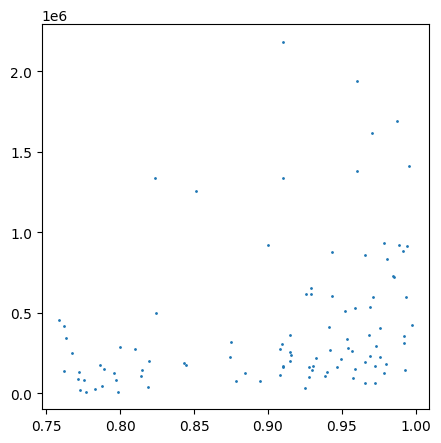

In [44]:
plt.figure(figsize=(5, 5))
plt.scatter(ave_areas, scores, s=1)
plt.show()

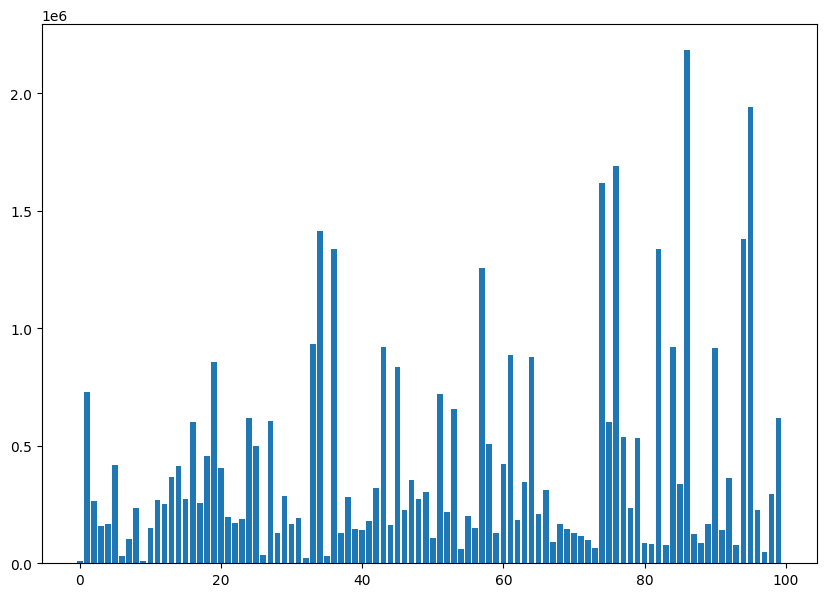

In [45]:
scores = [env.score for env in envs]
indexes = [i for i in range(N)]

plt.figure(figsize=(10, 7))
plt.bar(indexes, scores)
plt.show()

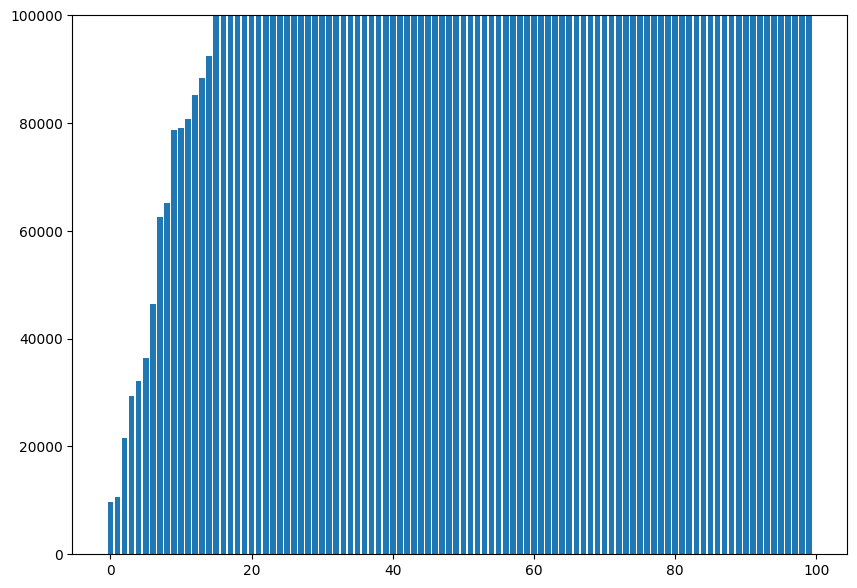

In [46]:
plt.figure(figsize=(10, 7))
plt.bar(indexes, sorted(scores))
plt.ylim(0, 10**5)
plt.show()

In [47]:
envs[0].ans[1]

[0, 772, 217, 1000]

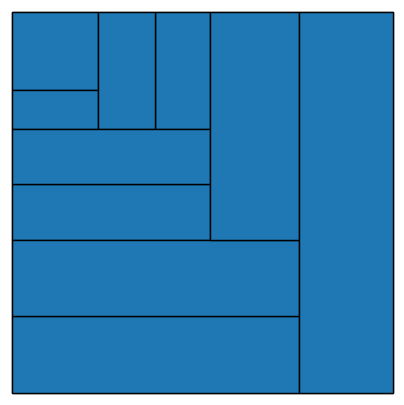

In [48]:
test_points = envs[0].ans[-envs[0].N:]

def display_map(points):
    fig = plt.figure(figsize=(5, 5))
    ax = plt.axes()

    r = patches.Rectangle(xy=(0, 0), width=1000, height=1000, ec='#000000', fill=False)
    ax.add_patch(r)

    for vec in points:
        x1, y1, x2, y2 = vec[0], vec[1], vec[2], vec[3]
        w, h = x2 - x1, y2 - y1
        r = patches.Rectangle(xy=(x1, y1), width=w, height=h, ec='#000000', fill=True)
        ax.add_patch(r)

    plt.xlim(-5, 1005)
    plt.ylim(-5, 1005)
    plt.axis('off')
    ax.set_aspect('equal')
    plt.show()

display_map(test_points)